In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [42]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

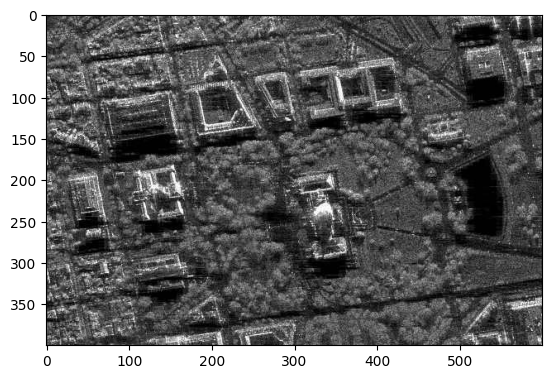

In [6]:
plt.imshow(image)

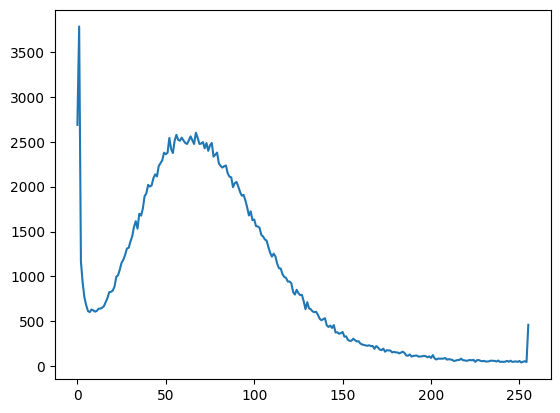

In [12]:
gray = image[:, :, 0]
hist = cv2.calcHist([gray], [0], None, [256], (0, 256), accumulate=False)
plt.plot(hist)

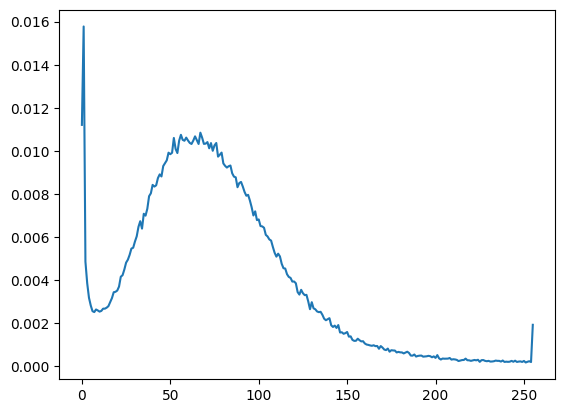

In [13]:
hist_norm = hist / (image.shape[0] * image.shape[1])
plt.plot(hist_norm)

In [37]:
from skimage.metrics import structural_similarity, mean_squared_error

In [43]:
image_norm = image_gray / 255.0

gamma_l1 = (255 * image_norm ** 0.5).astype('uint8')
gamma_m1 = (255 * image_norm ** 2).astype('uint8')

In [45]:
ssim_l1 = structural_similarity(image_gray, gamma_l1)
ssim_m1 = structural_similarity(image_gray, gamma_m1)

mse_l1 = mean_squared_error(image_gray, gamma_l1)
mse_m1 = mean_squared_error(image_gray, gamma_m1)

print("Gamma = 0.5", f'SSIM: {ssim_l1}', f'MSE: {mse_l1}', sep='\n')
print('\nGamma = 2', f'SSIM: {ssim_m1}', f'MSE: {mse_m1}', sep='\n')

Gamma = 0.5
SSIM: 0.7875008686792752
MSE: 3250.429145833333

Gamma = 2
SSIM: 0.5270459922820343
MSE: 2383.7636375


**Статистическая цветокоррекция**

In [46]:
mean = image_gray.mean()

In [47]:
std = image_gray.std()

In [48]:
print(mean, std)

74.94157083333333 43.658465466227916


In [49]:
eq_gray = cv2.equalizeHist(image_gray)

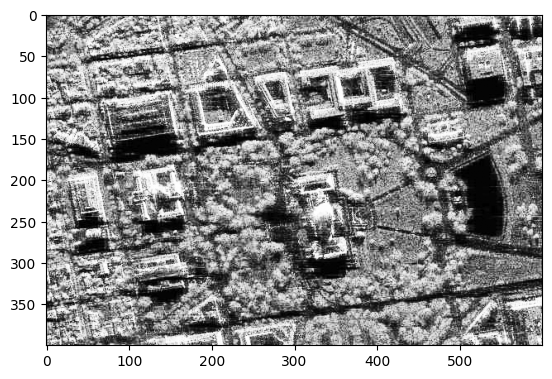

In [50]:
plt.imshow(eq_gray, cmap='gray')

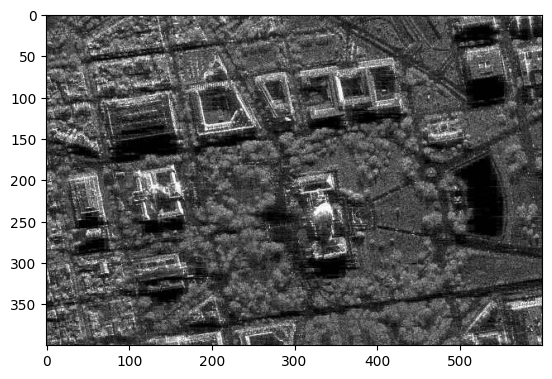

In [33]:
plt.imshow(image_gray, cmap='gray')

In [51]:
target_mean = eq_gray.mean()
target_std = eq_gray.std()

In [54]:
print(target_mean, target_std)

127.02563333333333 74.26964841889017


In [52]:
standard = (image_gray - mean) / std
correction = standard * target_std + target_mean

In [53]:
corrected = np.clip(correction, 0, 255).astype(np.uint8)

In [56]:
print(corrected.mean(), corrected.std())

123.1181375 65.3025763098039


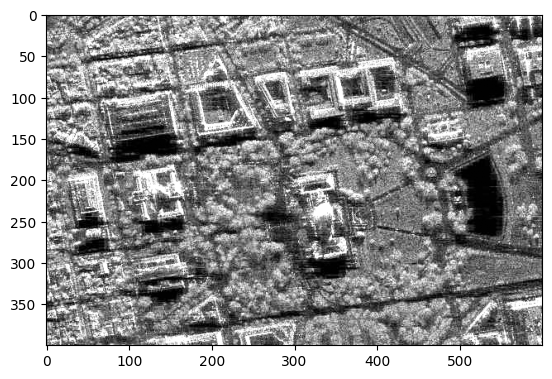

In [57]:
plt.imshow(corrected, cmap='gray')

**Пороговая фильтрация**

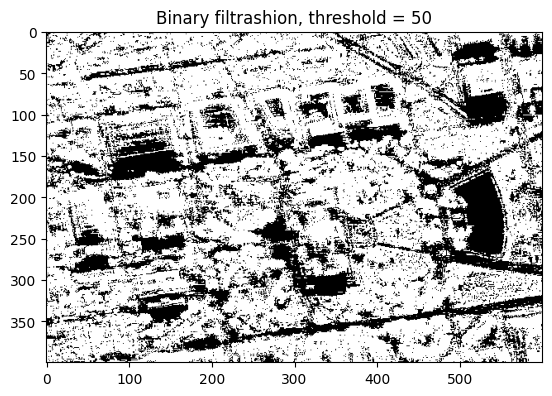

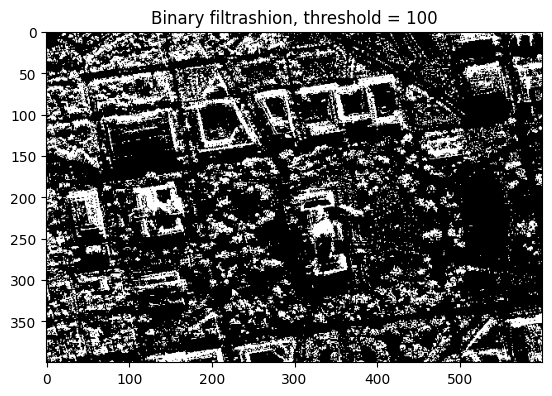

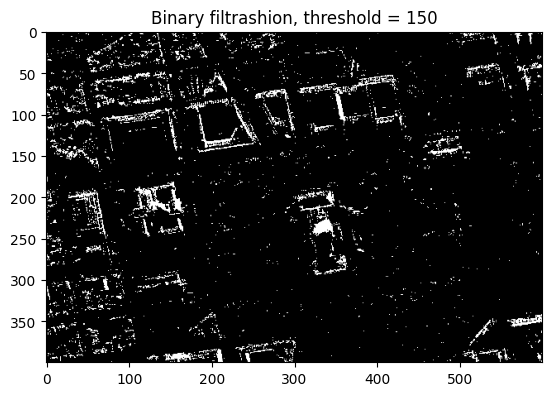

In [59]:
for threshold in [50, 100, 150]:
    _, binary = cv2.threshold(image_gray, threshold, 255, cv2.THRESH_BINARY)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Binary filtrashion, threshold = {threshold}')
    plt.show()